# **Pneumonia Detection using Computer Vision**

**AIM:**
- To train various models (CNN and transformer based) on patient's Chest X ray dataset and predict weather patient has pneumonia or not.
- Train and tune the models to get best result possible.
- Compare the models based on various metrics like Acuracy, Precession, F1, number of parameters, training time, etc.
- Deploy the best model on HuggingFace.

- Pneumonia is an inflammatory condition of the lung primarily affecting the small air sacs known as alveoli.
- Symptoms: combination of productive or dry cough, chest pain, fever, and difficulty in breathing. The severity of the condition is variable.
- Usually caused by infection with viruses or bacteria.

**Pneumonia causes lung tissue to swell (inflammation) and can cause fluid or pus in lungs.**

More about Pneumonia:
1. [Pneumonia causes, symptoms and treatment](https://my.clevelandclinic.org/health/diseases/4471-pneumonia)
2. [Chest X-Ray: Pneumonia Vs Normal](https://radiologyinplainenglish.com/chest-x-ray-pneumonia-vs-normal/)


<div style="display:flex; gap:10px;">
<img src="https://my.clevelandclinic.org/-/scassets/images/org/health/articles/4471-pneumonia-01" width="300">
<img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.verywellhealth.com%2Fthmb%2FtpYTWdo0Sf2Cx_UqX58nrMhbFUY%3D%2F1500x0%2Ffilters%3Ano_upscale()%3Amax_bytes(150000)%3Astrip_icc()%2Fwhat-are-alveoli-2249043-01-94dfddd4dfe9488b8056d586824c7c36.png&f=1&nofb=1&ipt=66fa09d8082244ab4c0e096d2459bdfe745b31e3e8ddb7f62fe4fb38f90ab100" width="400">  
</div>

## 0. Install required libraries


In [23]:
!pip install torchinfo
!pip install torchmetrics
!pip install wandb

## 1. Setup project directory

The project directory is set to folder: `MyDrive/Colab Notebooks/My Projects/Pneumonia Detection` in drive. For this the drive must be mounted.

**Folder Structure**

```
Pneumonia Detection/
│
├── data/
│   ├──chest_xray/
│      ├── train/
│      ├── test/
│
├── src/
|   |
│   ├── dataset.py
│   ├── transform.py
│   ├── dataloader.py
│   ├── predictions.py
│   ├── plots.py
│   ├── utils.py
|   |
│   ├── trainer/
│   |   ├── experiment.py
│   |   ├── transfer_learning_experiment.py
│   |   ├── fine_tuning_experiment.py
│   |   ├── loop.py
│   |   ├── train.py
│   │
│   ├── models/
│       ├── model.py
│       ├── architectures/
│            ├── resnet50.py
│            ├── densenet121.py
│            ├── efficientnet_b2.py
│            ├── vit_b_16.py
|
│
├── artifacts/
│   ├── models/
│
|
├── train.py
├── pneumonia_detection.ipynb
├── .gitignore
├── config.yaml
└── README.md
```

### 1.1 Detect platform

In [3]:
import os
import sys

def detect_platform() -> str:
    """
    Detects the current execution platform.

    Returns:
        str: one of "kaggle" or "colab"

    Raises:
        EnvironmentError: if the platform cannot be identified
    """

    # Kaggle sets this env variable in every kernel (most reliable signal)
    if "KAGGLE_DATA_PROXY_TOKEN" in os.environ:
        return "kaggle"

    # Colab has google.colab as an importable package
    try:
        import google.colab
        return "colab"
    except ImportError:
        pass

    raise EnvironmentError(
        "[ERROR] Could not detect platform. "
        "Only 'colab' and 'kaggle' are supported."
    )

PLATFORM = detect_platform()
print(f"[INFO] Running on: {PLATFORM}")

[INFO] Running on: colab


### 1.2 Download src folder from GitHub (modular scripts)

In [4]:
from pathlib import Path

# ── Repo config ─────────────────────────────────────────────────────
GITHUB_REPO_URL = "https://github.com/Mr-Atanu-Roy/Pneumonia-Detection-CV"
REPO_NAME       = "pneumonia-detection"

# ── Platform-specific paths ─────────────────────────────────────────
if PLATFORM == "colab":
    # Repo cloned into Colab's fast ephemeral storage — fresh every session
    REPO_DIR    = Path(f"/content/{REPO_NAME}")
    PROJECT_DIR = Path(f"/content/")

    # # Data and artifacts still persist on Drive
    # from google.colab import drive
    # drive.mount("/content/drive", force_remount=False)
    # PROJECT_DIR  = Path("/content/drive/MyDrive/Colab Notebooks/My Projects/Pneumonia Detection")
    # PROJECT_DIR.mkdir(parents=True, exist_ok=True)

elif PLATFORM == "kaggle":
    REPO_DIR    = Path(f"/kaggle/working/{REPO_NAME}")
    PROJECT_DIR = Path("/kaggle/working")

# ── Clone the repo ───────────────────────────────────────────────────
def setup_repo(repo_url: str, repo_dir: Path, platform: str) -> None:
    """
    Clones fresh the GitHub repo into platform-appropriate ephemeral storage.
    Colab (/content/) and Kaggle (/kaggle/working/).

    Args:
        repo_url : full HTTPS GitHub URL of the repo
        repo_dir : local Path where the repo will be cloned
        platform : "colab" or "kaggle"
    """
    if repo_dir.exists():
        # Runtime was restarted without full reset — repo already present
        print(f"[INFO] Repo already exists at {repo_dir}. Skipping clone.")
    else:
        print(f"[INFO] Cloning repo into {repo_dir}...")
        !git clone {repo_url} {repo_dir}            #clone
        !rm {repo_dir}/pneumonia_detection.ipynb    #remove notebook file
        print(f"[INFO] Repo ready at: {repo_dir}")

setup_repo(GITHUB_REPO_URL, REPO_DIR, PLATFORM)

# ── Add repo root to sys.path ────────────────────────────────────────
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
    print(f"[INFO] Added to sys.path: {REPO_DIR}")

[INFO] Cloning repo into /content/pneumonia-detection...
Cloning into '/content/pneumonia-detection'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (48/48), done.
Receiving objects: 100% (71/71), 60.08 KiB | 976.00 KiB/s, done.
remote: Total 71 (delta 40), reused 54 (delta 23), pack-reused 0 (from 0)
Resolving deltas: 100% (40/40), done.
[INFO] Repo ready at: /content/pneumonia-detection
[INFO] Added to sys.path: /content/pneumonia-detection


### 1.3 Setup libs

In [5]:
from src.utils import set_seeds
set_seeds()

In [6]:
from src.utils import wandb_login

wandb_login(PLATFORM)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: atanu-roy (atanu-roy-none) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[INFO] WandB login successful.


In [7]:
import torch

#set the device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2. Setup data directory and download the dataset

**Dataset Description**

1. **Dataset used:** [chest-xray-pneumonia (Kaggle)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

2. **Dataset description:** The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal).

The dataset contains very less validation sets (16 total). So the validation set is merged with the train. And then the train is splited into $80 \% $ training and $20 \% $ validation splits.

### 2.1 Download the data

In [8]:
PROJECT_DIR, REPO_DIR

(PosixPath('/content'), PosixPath('/content/pneumonia-detection'))

In [9]:
from src.dataset import download_data

data_dir = download_data(target_dir=PROJECT_DIR / "data", platform=PLATFORM)

[INFO] Downloading dataset from Kaggle via kagglehub...
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
[INFO] Download complete.
[INFO] Organizing data into /content/data/chest_xray...
[INFO] Copied 'train' split successfully.
[INFO] Copied 'test' split successfully.
[INFO] Merged val/ into train/ successfully.
[SUCCESS] Dataset ready at: /content/data/chest_xray


In [10]:
print(f"Path for data is: {data_dir}")

Path for data is: /content/data/chest_xray


In [11]:
#set up some imp. paths

train_val_dir = data_dir / "train"  #contains both train and val data
test_dir = data_dir / "test"

artifacts_dir = PROJECT_DIR / "artifacts"

print(f"Train & Val data path: {train_val_dir}")
print(f"Test data path: {test_dir}")
print(f"Artifacts path: {artifacts_dir}")

Train & Val data path: /content/data/chest_xray/train
Test data path: /content/data/chest_xray/test
Artifacts path: /content/artifacts


### 2.2 Checking data distribution

In [12]:
#checking data distribution for train val data
import os

# total normal data count
normal_count = len(os.listdir(train_val_dir / "NORMAL"))

#total pneumonia data count
pneumonia_count = len(os.listdir(train_val_dir / "PNEUMONIA"))

#total count
total_data_count = normal_count + pneumonia_count

#percentage
normal_percentage = (normal_count / total_data_count) * 100
pneumonia_percentage = (pneumonia_count / total_data_count) * 100

print(f"Total normal data count: {normal_count} ({normal_percentage:.2f}%)")
print(f"Total pneumonia data count: {pneumonia_count} ({pneumonia_percentage:.2f}%)")
print(f"Total data count: {total_data_count}")

Total normal data count: 1351 (25.80%)
Total pneumonia data count: 3885 (74.20%)
Total data count: 5236


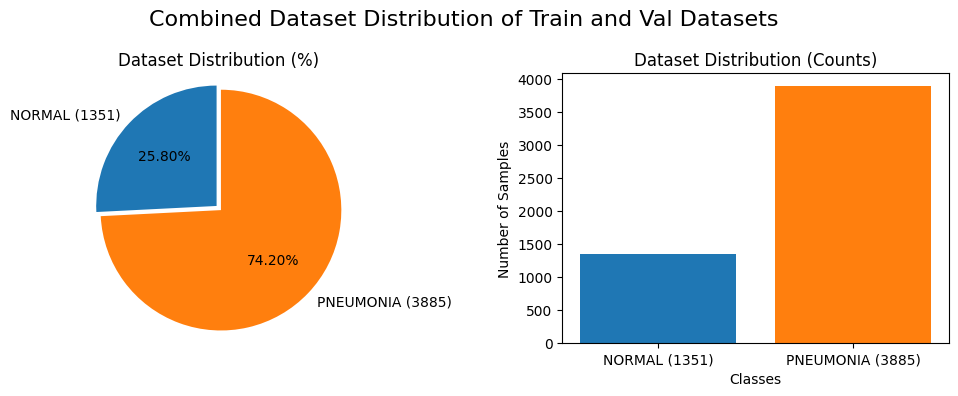

In [13]:
import matplotlib.pyplot as plt

# Labels and sizes
labels = [f"NORMAL ({normal_count})", f"PNEUMONIA ({pneumonia_count})"]

# labels = ['NORMAL', 'PNEUMONIA']
sizes = [normal_percentage, pneumonia_percentage]
counts = [normal_count, pneumonia_count]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# ---- Pie Chart ----
axs[0].pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90,
    explode=(0.05, 0)
)
axs[0].set_title('Dataset Distribution (%)')
axs[0].axis('equal')

# ---- Bar Plot ----
axs[1].bar(labels, counts, color=["C0", "C1"])
axs[1].set_title('Dataset Distribution (Counts)')
axs[1].set_xlabel('Classes')
axs[1].set_ylabel('Number of Samples')

# Add a main title to the combined plot
fig.suptitle('Combined Dataset Distribution of Train and Val Datasets', fontsize=16)

plt.tight_layout()
plt.show()

In [16]:
pos_weight = total_data_count / (2 * pneumonia_count)
neg_weight = total_data_count / (2 * normal_count)

print(f"pos_weight: {pos_weight}, neg_weight: {neg_weight}")

pos_weight: 0.6738738738738739, neg_weight: 1.9378238341968912


- **The dataset is imbalanced dataset**. $N:P ≈ 1:3$
- Use of **weighted loss function** with `pos_weight=0.6738` for training will be benifitial

### 2.3 Update base `config.yaml`

In [17]:
import os
from src.utils import update_yaml_config

update_yaml_config(
    config_path = REPO_DIR / "config.yaml",
    updates = {
        "paths": {
            "train_val_dir": str(train_val_dir),
            "test_dir": str(test_dir),
            "artifacts_dir": str(artifacts_dir)
        },
        "data": {
            "pos_weight": round(pos_weight, 7)
        }
    }
)

[INFO] Config file updated successfully.


### 2.4 Split the training data into train and val splits

$80 \% $ training and $20 \% $ validation split from train data. This is done inside the `src.dataloader.create_datloader()` function which returns the train, val, test dataloaders. (See pt. 3 below)

## 3. Create transforms for test and train data and create train, val and test dataloaders

- The transforms are created seperatly for train and test sets
    

In [18]:
from src.transform import train_transforms, test_transforms
from src.dataloader import create_dataloaders

BATCH_SIZE = 32

train_dataloader, val_dataloader, test_dataloader, class_names = create_dataloaders(
    train_val_dir=train_val_dir,
    test_dir=test_dir,
    train_transform=train_transforms,
    test_transform=test_transforms,
    val_size=0.2,
    batch_size=BATCH_SIZE,
    num_workers=os.cpu_count(),
    persistent_workers=True if os.cpu_count() > 0 else False
)

print(f"[INFO] Dataloaders created successfully with classes: {class_names}")

[INFO] Dataloaders created successfully with classes: ['NORMAL', 'PNEUMONIA']


In [19]:
print(f"Classes: {class_names}")
print(f"Train batches: {len(train_dataloader)} each of batch size {BATCH_SIZE}")
print(f"Val batches: {len(val_dataloader)} each of batch size {BATCH_SIZE}")
print(f"Test batches: {len(test_dataloader)} each of batch size {BATCH_SIZE}")

Classes: ['NORMAL', 'PNEUMONIA']
Train batches: 131 each of batch size 32
Val batches: 33 each of batch size 32
Test batches: 20 each of batch size 32


### 3.1 Visualize some random data from dataloaders

#### 3.1.1 Train dataloader

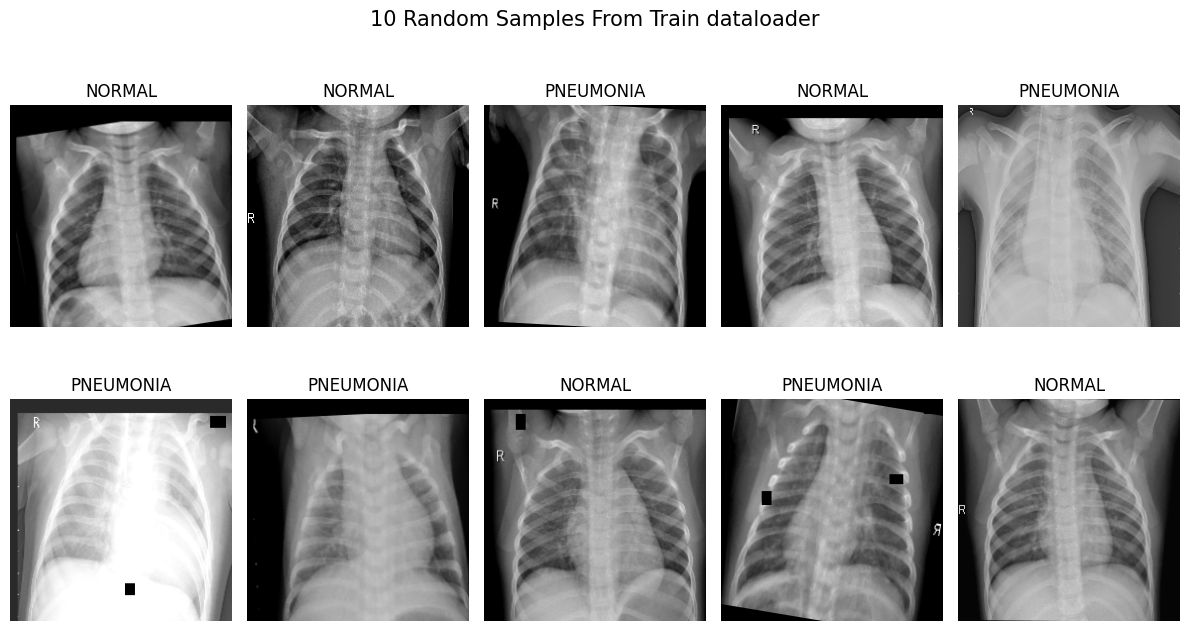

In [20]:
from src.plots import plot_data

plot_data(dataloader=train_dataloader, class_names=class_names, k=10, title="10 Random Samples From Train dataloader")

#### 3.1.2 Val dataloader

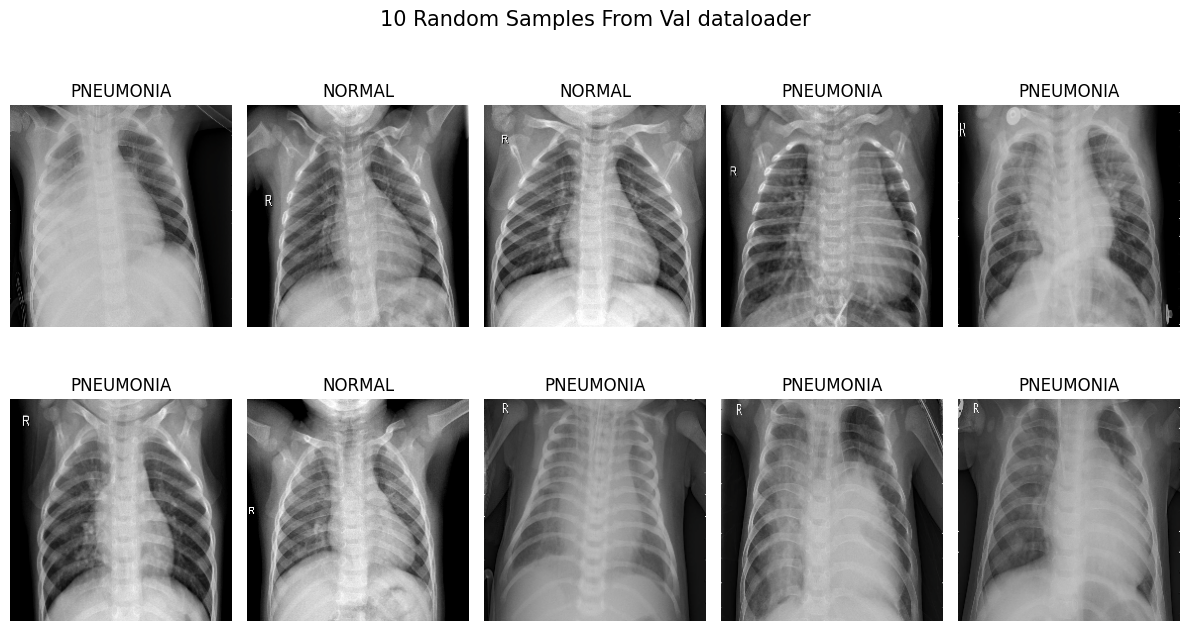

In [21]:
plot_data(dataloader=val_dataloader, class_names=class_names, k=10, title="10 Random Samples From Val dataloader")

#### 3.1.3 Test dataloader

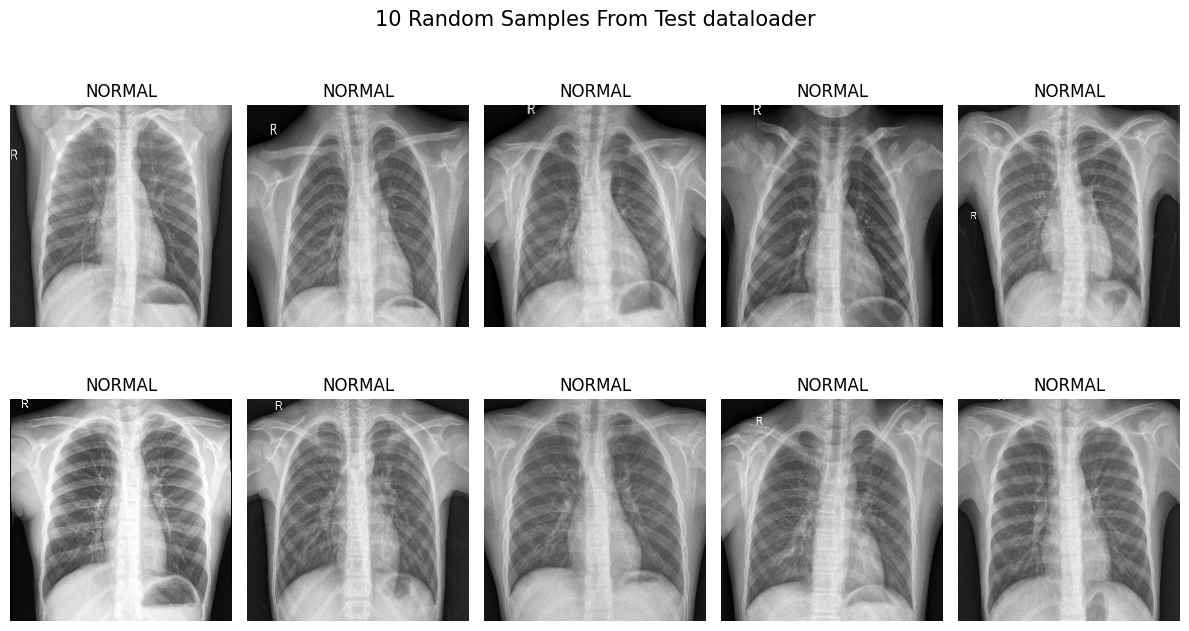

In [22]:
plot_data(dataloader=test_dataloader, class_names=class_names, k=10, title="10 Random Samples From Test dataloader")

## 4. Model building

4 models are choosen as each of them differ in application and architecture heavily from one another:
- Resnet 50: widely used baseline model
- DenseNet: Medically justified via CheXNet (Stanford's landmark chest X-ray paper, 2017)
- EffNet b2: Efficient architecture CNN model
- ViT-B/16: Transformer based modern architecture

All pretrained models are trained using transfer learning.
The Weights obtained from training on IMAGENET1K_V1 dataset are used for every model.

The model architecture can be found in the `src/models/architectures/`

In [ ]:
from src.trainer.experiment import run_experiment

run_experiment(
    model_name="efficientnet_b2",
    epochs=3,
    ft_epochs=2,
    n_layers=2
)